# Image Classification with CNNs in PyTorch using CIFAR-10 Dataset

The objective of this notebook is to build a **Convolutional Neural Network (CNN)** for image classification using the **CIFAR-10 dataset**. The model will be trained to classify images into 10 classes and evaluated for accuracy. This notebook will explore CNNs' ability to extract spatial features for improved classification performance.


# Data Description

The **CIFAR-10 dataset** (Canadian Institute for Advanced Research) is one of the most widely used datasets for image classification tasks, particularly in the field of deep learning. It contains **60,000 images** distributed across **10 classes**, with each class containing **6,000 images**. The images are **32x32 pixels** in size, which makes them small by modern image standards but still challenging due to the variability in object orientations, backgrounds, and lighting conditions.

This dataset is often used as a benchmark to evaluate the performance of deep learning models, especially **Convolutional Neural Networks (CNNs)**, in solving image classification problems.

### Key Features

| Feature              | Description                                                |
|----------------------|------------------------------------------------------------|
| **Number of Classes** | 10                                                         |
| **Total Images**      | 60,000                                                     |
| **Image Dimensions**  | 32x32 pixels                                               |
| **Color Channels**    | RGB (3 channels: Red, Green, Blue)                         |
| **Train/Test Split**  | 50,000 training images and 10,000 test images              |
| **Classes**           | Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck |


### Using CNNs for Image Classification with CIFAR-10

In this example, we’ll build a simple CNN model to classify the CIFAR-10 images. Our CNN will consist of:

- **Convolutional Layers**: To detect local features in the image.
- **Activation Functions (ReLU)**: To introduce non-linearity and help the network learn more complex patterns.
- **Max-Pooling Layers**: To downsample the image and reduce computation.
- **Fully Connected Layers**: To classify the image into one of the 10 classes.

**CNNs** excel at image classification tasks like **CIFAR-10** by learning spatial hierarchies of features, outperforming traditional fully connected networks. Despite being small, the CIFAR-10 dataset presents challenges due to varied object appearances and backgrounds.

It serves as a great foundation for learning and benchmarking CNNs, enabling you to observe how well the model generalizes to unseen data and optimizes image classification.


# 1. Import Libraries and Set Hyperparameters


**This cell imports required libraries like PyTorch, TorchVision, NumPy, and Matplotlib. They are used for building models, handling data, and visualizing results.**

In [1]:
# Necessary imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import random

## Data Preparation

We will use the `torchvision.datasets.CIFAR10` class to load CIFAR10 dataset.

By default, the loaded data are in `PIL.Image` format, which are perfect for visualization. Let's take a look!

In [2]:

import torchvision
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


def get_datasets(train_transforms=(), val_transforms=()):
    r"""
    Returns the CIFAR-10 training and validation datasets with corresponding
    transforms.

    `*_transforms` represent optional transformations, e.g., conversion to
    PyTorch tensors, preprocessing, etc.
    """
    train_set = torchvision.datasets.CIFAR10(
        "./data",
        train=True,
        download=True,
        transform=torchvision.transforms.Compose(train_transforms),
    )
    val_set = torchvision.datasets.CIFAR10(
        "./data",
        train=False,
        download=True,
        transform=torchvision.transforms.Compose(val_transforms),
    )
    return train_set, val_set

In [3]:
df_train,df_val = get_datasets()

In [5]:
type(df_train)

torchvision.datasets.cifar.CIFAR10

In [6]:
dir(df_train)

['__add__',
 '__annotations__',
 '__class__',
 '__class_getitem__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__orig_bases__',
 '__parameters__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_check_integrity',
 '_format_transform_repr',
 '_load_meta',
 '_repr_indent',
 'base_folder',
 'class_to_idx',
 'classes',
 'data',
 'download',
 'extra_repr',
 'filename',
 'meta',
 'root',
 'target_transform',
 'targets',
 'test_list',
 'tgz_md5',
 'train',
 'train_list',
 'transform',
 'transforms',
 'url']

In [7]:
df_train.url

'https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz'

In [9]:
len(df_train.targets)

50000

In [11]:
img_names=df_train.classes

In [13]:
type(df_train.data)

numpy.ndarray

In [14]:
df_train.train

True

In [16]:
y_train = df_train.targets

In [17]:
x_train = df_train.data

In [18]:
y_train[0]

6

In [20]:
x_train.shape

(50000, 32, 32, 3)

In [22]:
type(x_train[0])

numpy.ndarray

frog


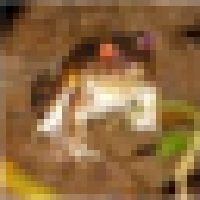

In [28]:
print(img_names[df_train[0][1]])
df_train[0][0].resize((200,200),resample=Image.NEAREST)

## Converting to tensor format

In [30]:
data_transforms = [
    # Converts PIL images into tensors with values in [0, 1].
    # For RGB images, the output shape will be [3, width, height], where `3`
    # represents three channels.
    torchvision.transforms.ToTensor(),
    # Normalize each of the three channels so that they have 0 mean and 1 std.
    # Normalization is generally a good idea and particularly useful when different
    # parts of your input have very different statistics.
    torchvision.transforms.Normalize(
        mean=[.5,.5,.5], std=[.5, .5, 0.5]
    ),
]


In [31]:
train,val = get_datasets(data_transforms,data_transforms)

In [33]:
train.data.shape

(50000, 32, 32, 3)

In [34]:
# Hyperparameters
BATCH_SIZE = 32  # Number of images processed in one batch
learning_rate = 0.001  # Learning rate for the optimizer
num_epochs = (
    5  # Number of times the model will iterate over the entire training dataset
)

In [35]:
trainloader = torch.utils.data.DataLoader(
    train, batch_size=BATCH_SIZE, shuffle=True, num_workers=2
)

In [36]:
testloader = torch.utils.data.DataLoader(
    val, batch_size=BATCH_SIZE, shuffle=False, num_workers=2
)

In [37]:
a,b = train[0]

In [38]:
a.shape

torch.Size([3, 32, 32])

In [39]:
a.type

<function Tensor.type>

In [40]:
a.dtype

torch.float32

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


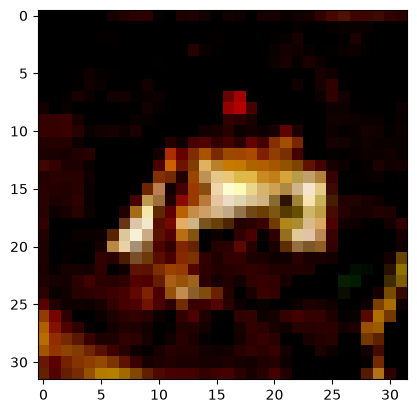

In [43]:
 # Data is a tensor of shape [C, W, H]  (C is the channel dimension, 3 for RGB)
    # Put channel at last
a=a.permute(1,2,0)
plt.imshow(a)

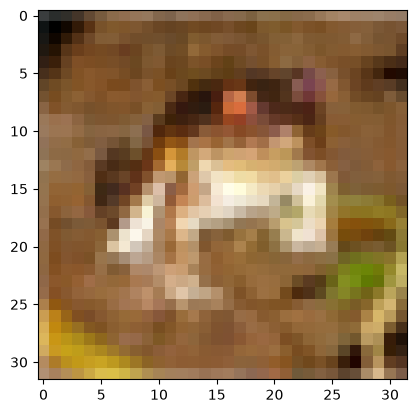

In [47]:
plt.imshow(
    (torchvision.utils.make_grid(a) / 2)+.5
)  # Unnormalize and permute
plt.show()

In [66]:
data = a*torch.as_tensor([.5,.5,.5])+torch.as_tensor([.5,.5,.5])

In [67]:
data.shape

torch.Size([32, 32, 3])

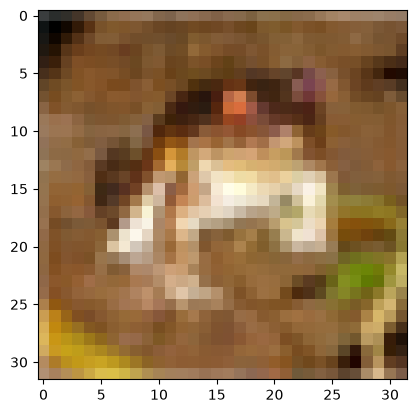

In [68]:
plt.imshow(data)
plt.show()

In [69]:
# def visualize_tensor_data(data: torch.Tensor, label: int):
#     # Data is a tensor of shape [C, W, H]  (C is the channel dimension, 3 for RGB)
#     # Put channel at last
#     data = data.permute(1, 2, 0)
#     # Un-normalize
#     data = data * torch.as_tensor([0.2470, 0.2435, 0.2616]) + torch.as_tensor(
#         [0.4914, 0.4822, 0.4465] #         mean=[0.4914, 0.4822, 0.4465], std=[0.2470, 0.2435, 0.2616]
#
#     )
#     plt.imshow(data)
#     plt.axis("off")
#     plt.title(f"Label = {img_names[label]}")
#
#
# visualize_tensor_data(data, b)

In [70]:
data.shape

torch.Size([32, 32, 3])

In [71]:
data

tensor([[[0.2314, 0.2431, 0.2471],
         [0.1686, 0.1804, 0.1765],
         [0.1961, 0.1882, 0.1686],
         ...,
         [0.6196, 0.5176, 0.4235],
         [0.5961, 0.4902, 0.4000],
         [0.5804, 0.4863, 0.4039]],

        [[0.0627, 0.0784, 0.0784],
         [0.0000, 0.0000, 0.0000],
         [0.0706, 0.0314, 0.0000],
         ...,
         [0.4824, 0.3451, 0.2157],
         [0.4667, 0.3255, 0.1961],
         [0.4784, 0.3412, 0.2235]],

        [[0.0980, 0.0941, 0.0824],
         [0.0627, 0.0275, 0.0000],
         [0.1922, 0.1059, 0.0314],
         ...,
         [0.4627, 0.3294, 0.1961],
         [0.4706, 0.3294, 0.1961],
         [0.4275, 0.2863, 0.1647]],

        ...,

        [[0.8157, 0.6667, 0.3765],
         [0.7882, 0.6000, 0.1333],
         [0.7765, 0.6314, 0.1020],
         ...,
         [0.6275, 0.5216, 0.2745],
         [0.2196, 0.1216, 0.0275],
         [0.2078, 0.1333, 0.0784]],

        [[0.7059, 0.5451, 0.3765],
         [0.6784, 0.4824, 0.1647],
         [0.

In [ ]:
class Conv_Net(torch.nn.Module):
    def __init__(self):
        super(Conv_Net,self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3,32,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # Output: 32 x 16 x 16
            nn.Conv2d(32,32,kernel_size=3,padding=1),  # Conv Layer 2
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # Output: 32 x 8 x 8

        )

In [72]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # Conv Layer 1
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # Output: 32 x 16 x 16
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # Conv Layer 2
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # Output: 64 x 8 x 8
            nn.Conv2d(64, 128, kernel_size=3, padding=1),  # Conv Layer 3
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # Output: 128 x 4 x 4
            nn.Flatten(),  # Flatten before FC
            nn.Linear(128 * 4 * 4, 512),  # FC Layer 1
            nn.ReLU(),
            nn.Linear(512, 10),  # Output Layer
        )

    def forward(self, x):
        return self.model(x)

In [73]:
cnn = SimpleCNN()

In [74]:
cnn

SimpleCNN(
  (model): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Flatten(start_dim=1, end_dim=-1)
    (10): Linear(in_features=2048, out_features=512, bias=True)
    (11): ReLU()
    (12): Linear(in_features=512, out_features=10, bias=True)
  )
)

In [75]:
device  = "mps"
cnn = cnn.to(device)

In [76]:
criterion = nn.CrossEntropyLoss()  # Loss function used for multi-class classification
optimizer = torch.optim.Adam(
    cnn.parameters(), lr=learning_rate
)  # Optimizer for adjusting model parameters

In [77]:
# Training Loop: Train the model for a specified number of epochs
for epoch in range(num_epochs):
    cnn.train()  # Set model to training mode
    train_loss = 0.0

    for images, labels in trainloader:
        images, labels = (
            images.to(device),
            labels.to(device),
        )  # Move to device (GPU/CPU)
        predictions = cnn(images)  # Forward pass

        # Compute loss and backpropagate
        loss = criterion(predictions, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    # Print loss for the current epoch
    print(
        f"Epoch [{epoch + 1}/{num_epochs}] | Loss: {train_loss / len(trainloader):.4f}"
    )

Epoch [1/5] | Loss: 1.2722
Epoch [2/5] | Loss: 0.8410
Epoch [3/5] | Loss: 0.6613
Epoch [4/5] | Loss: 0.5276
Epoch [5/5] | Loss: 0.4084


In [78]:
# --- Testing Phase: Evaluate the trained model on the test set ---
correct, total = 0, 0  # Counters for correct and total predictions

cnn.eval()  # Set the model to evaluation mode
with torch.no_grad():  # Disable gradients for inference
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = cnn(images)

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# Final stats
incorrect = total - correct
accuracy = 100 * correct / total

print(f"Total validated points: {total}")
print(f"Correct classifications: {correct}")
print(f"Incorrect classifications: {incorrect}")
print(f"Test Accuracy: {accuracy:.2f}%")

Total validated points: 10000
Correct classifications: 7618
Incorrect classifications: 2382
Test Accuracy: 76.18%


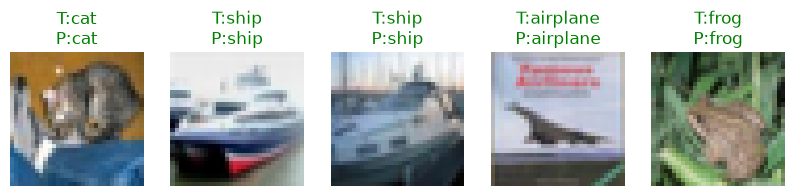

In [80]:
# Function to visualize random predictions from the test set
def visualize_predictions(model, testloader, num_images=5, device="cpu"):
    model.eval()
    images, labels = next(iter(testloader))  # take one batch
    images, labels = images.to(device), labels.to(device)

    preds = model(images).argmax(1)  # forward + predicted classes
    fig, axes = plt.subplots(1, num_images, figsize=(10, 5))

    for i, ax in enumerate(axes[:num_images]):
        img = images[i].cpu().permute(1, 2, 0).numpy() / 2 + 0.5  # unnormalize
        ax.imshow(img)
        ax.axis("off")

        true, pred = val.classes[labels[i]], val.classes[preds[i]]
        ax.set_title(f"T:{true}\nP:{pred}", color=("green" if true == pred else "red"))

    plt.show()


visualize_predictions(
    cnn, testloader, num_images=5, device=device
)  # Visualize predictions